# 05 Links to Other Indices

Compares the DPI against two external benchmarks:
1. Official FIA Championship Standings - Spearman rank correlation per season
2. OpenF1 lap telemetry - average gap to session fastest lap as an 
   independent pace metric for 2023 and 2024



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from pathlib import Path

In [2]:
PROCESSED_DIR = Path('../data/processed')
OUTPUT_DIR    = Path('../outputs')

norm_df = pd.read_csv(PROCESSED_DIR / 'dpi_final.csv')

print("Shape:", norm_df.shape)
print("\nColumns:", list(norm_df.columns))

Shape: (105, 24)

Columns: ['season', 'driver_id', 'driver_code', 'driver_name', 'constructor', 'races', 'total_points', 'points_per_race', 'avg_finish_position', 'finish_position_std', 'wins', 'podiums', 'dnfs', 'dnf_rate', 'avg_positions_gained', 'points_finish_rate', 'avg_quali_position', 'cluster', 'cluster_label', 'DPI', 'DPI_rank', 'official_rank', 'DPI_rank_season', 'rank_diff']


## Part 1: DPI vs Official FIA Championship Standings

The Spearman rank correlation coefficient measures how closely the DPI 
ranking agrees with the official FIA championship ranking each season. 
A value of 1 means perfect agreement, 0 means no relationship. 
Spearman is used rather than Pearson because we are comparing ranks 
rather than raw values.

In [3]:
results = []
for season in sorted(norm_df['season'].unique()):
    season_data = norm_df[norm_df['season'] == season].dropna()
    r, p = spearmanr(
        season_data['official_rank'],
        season_data['DPI_rank_season']
    )
    results.append({
        'season'    : season,
        'spearman_r': round(r, 3),
        'p_value'   : round(p, 4),
        'n_drivers' : len(season_data)
    })

spearman_df = pd.DataFrame(results)
print("Spearman Correlation — DPI vs Official FIA Standings:")
print(spearman_df.to_string(index=False))

Spearman Correlation — DPI vs Official FIA Standings:
 season  spearman_r  p_value  n_drivers
   2021       0.959      0.0         20
   2022       0.919      0.0         20
   2023       0.936      0.0         22
   2024       0.894      0.0         22
   2025       0.906      0.0         21


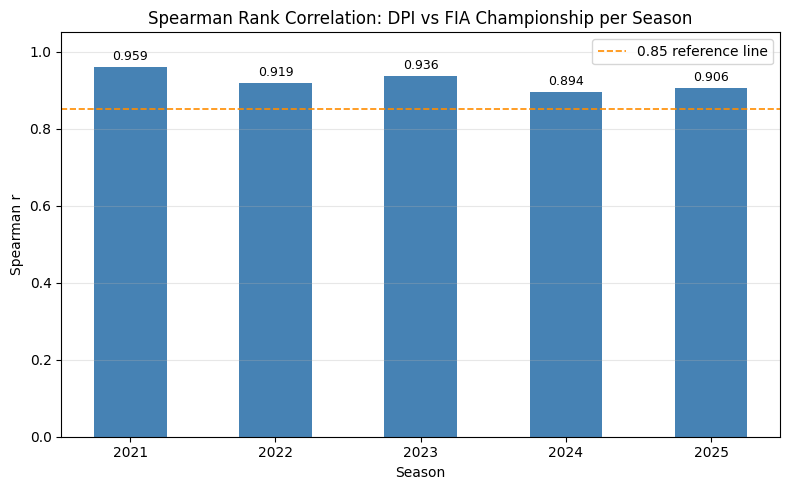

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    spearman_df['season'],
    spearman_df['spearman_r'],
    color='steelblue', width=0.5
)
ax.axhline(0.85, linestyle='--', color='darkorange',
           linewidth=1.2, label='0.85 reference line')
ax.set_ylim(0, 1.05)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_title('Spearman Rank Correlation: DPI vs FIA Championship per Season')
ax.set_xlabel('Season')
ax.set_ylabel('Spearman r')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'spearman_by_season.png', dpi=150)
plt.show()

## DPI vs Official Rank Scatter Plot

Visualises where DPI rank and official rank agree and where they diverge.
Points on the diagonal line represent perfect agreement. Points above 
the line mean the DPI ranks that driver higher than the official standings.

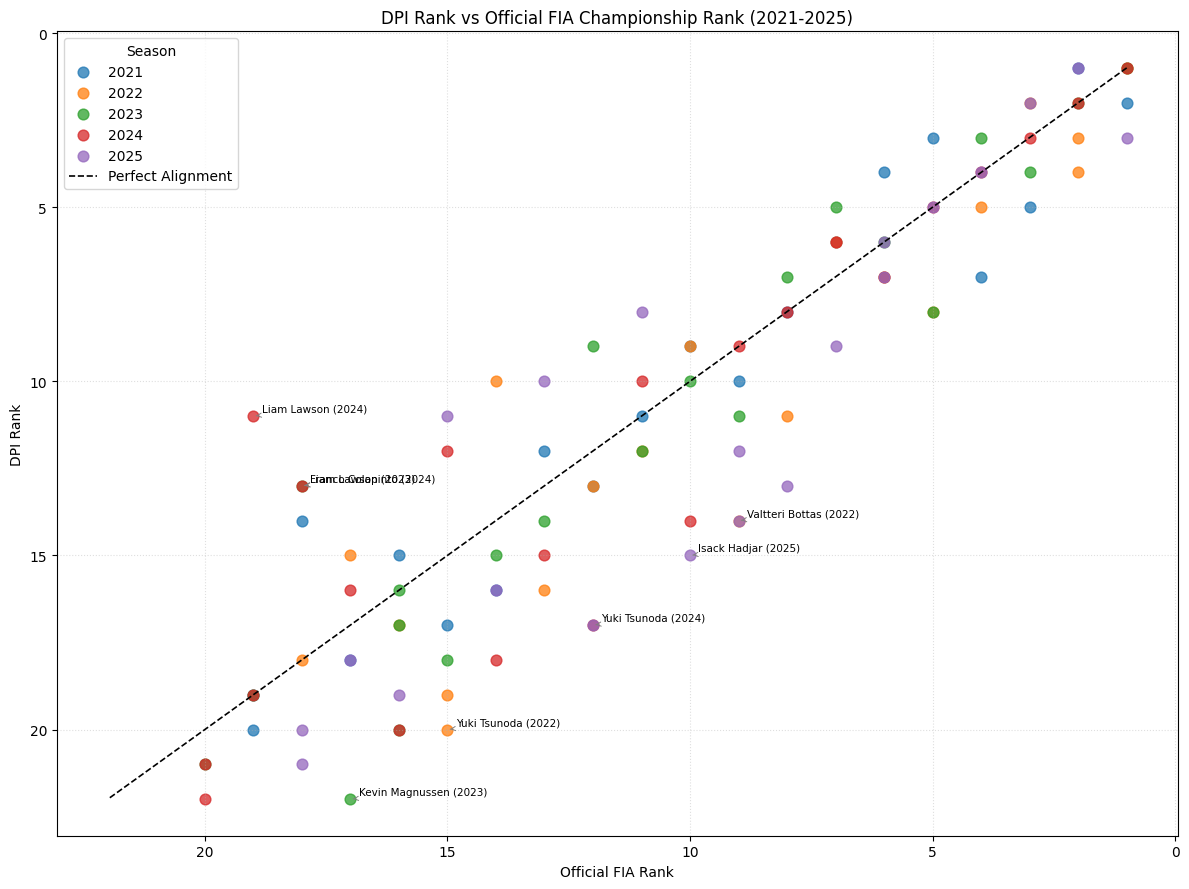

In [5]:
norm_df['abs_diff'] = norm_df['rank_diff'].abs()
top_outliers = norm_df.nlargest(8, 'abs_diff')

season_colors = {
    2021: '#1f77b4', 2022: '#ff7f0e',
    2023: '#2ca02c', 2024: '#d62728', 2025: '#9467bd'
}

fig, ax = plt.subplots(figsize=(12, 9))

for season, group in norm_df.groupby('season'):
    ax.scatter(
        group['official_rank'],
        group['DPI_rank_season'],
        label=str(season),
        color=season_colors.get(season, 'grey'),
        alpha=0.75, s=60
    )

for _, row in top_outliers.iterrows():
    ax.annotate(
        f"{row['driver_name']} ({int(row['season'])})",
        (row['official_rank'], row['DPI_rank_season']),
        xytext=(6, 3), textcoords='offset points',
        fontsize=7.5,
        arrowprops=dict(arrowstyle='->', color='grey', lw=0.7)
    )

max_r = int(max(norm_df['official_rank'].max(),
                norm_df['DPI_rank_season'].max()))
ax.plot([1, max_r], [1, max_r], 'k--', linewidth=1.2,
        label='Perfect Alignment')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_title('DPI Rank vs Official FIA Championship Rank (2021-2025)')
ax.set_xlabel('Official FIA Rank')
ax.set_ylabel('DPI Rank')
ax.legend(title='Season')
ax.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dpi_vs_official_rank.png', dpi=150)
plt.show()

In [6]:
print("Top 8 largest DPI vs FIA rank divergences:")
print(
    top_outliers[['season', 'driver_name', 'constructor',
                  'official_rank', 'DPI_rank_season', 'rank_diff']]
    .sort_values('rank_diff', key=abs, ascending=False)
    .to_string(index=False)
)

Top 8 largest DPI vs FIA rank divergences:
 season      driver_name  constructor  official_rank  DPI_rank_season  rank_diff
   2024      Liam Lawson   RB F1 Team           19.0             11.0        8.0
   2022  Valtteri Bottas   Alfa Romeo            9.0             14.0       -5.0
   2022     Yuki Tsunoda   AlphaTauri           15.0             20.0       -5.0
   2023  Kevin Magnussen Haas F1 Team           17.0             22.0       -5.0
   2023      Liam Lawson   AlphaTauri           18.0             13.0        5.0
   2024 Franco Colapinto     Williams           18.0             13.0        5.0
   2024     Yuki Tsunoda   RB F1 Team           12.0             17.0       -5.0
   2025     Isack Hadjar   RB F1 Team           10.0             15.0       -5.0


## Part 2 - OpenF1 Telemetry Validation

OpenF1 provides lap-level telemetry data independent of the Jolpica 
dataset. The metric used is average gap to the session fastest lap 
expressed as a percentage, a lower gap means faster pace. This gives 
a completely independent cross-check on whether DPI rankings agree 
with raw lap time performance.

Coverage is limited to 2023 and 2024 as OpenF1 data before 2023 
is incomplete.

In [11]:
import requests
import time

OPENF1_BASE        = 'https://api.openf1.org/v1'
VALIDATION_SEASONS = [2023, 2024]

def openf1_get(endpoint, params=None):
    url      = f"{OPENF1_BASE}/{endpoint}"
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    time.sleep(0.3)
    return response.json()

session_rows = []
for year in VALIDATION_SEASONS:
    sessions = openf1_get('sessions',
                          params={'year': year, 'session_type': 'Race'})
    for s in sessions:
        if not s.get('is_cancelled', False) and s['session_name'] == 'Race':
            session_rows.append({
                'session_key' : s['session_key'],
                'race_name'   : s['country_name'],
                'year'        : s['year']
            })

sessions_df = pd.DataFrame(session_rows)
print(f"Found {len(sessions_df)} race sessions")
print(sessions_df.groupby('year').size())

Found 46 race sessions
year
2023    22
2024    24
dtype: int64


In [12]:
all_laps = []

for _, session in sessions_df.iterrows():
    laps = openf1_get('laps',
                      params={'session_key': session['session_key']})
    if not laps:
        continue

    lap_df = pd.DataFrame(laps)
    if 'lap_duration' not in lap_df.columns:
        continue

    lap_df = lap_df.dropna(subset=['lap_duration'])
    lap_df = lap_df[lap_df['lap_duration'] > 60]

    fastest = (
        lap_df.groupby('driver_number')['lap_duration']
        .min()
        .reset_index()
        .rename(columns={'lap_duration': 'fastest_lap_s'})
    )
    fastest['session_key'] = session['session_key']
    fastest['race_name']   = session['race_name']
    fastest['year']        = session['year']
    all_laps.append(fastest)

laps_df = pd.concat(all_laps, ignore_index=True)

laps_df['session_best'] = laps_df.groupby('session_key')['fastest_lap_s'].transform('min')
laps_df['gap_pct']      = ((laps_df['fastest_lap_s'] - laps_df['session_best'])
                           / laps_df['session_best'] * 100)

print(f"Lap data collected: {len(laps_df)} driver-session rows")
print(f"Sessions covered:   {laps_df['session_key'].nunique()}")

Lap data collected: 895 driver-session rows
Sessions covered:   46


In [13]:
drivers_meta = openf1_get('drivers', 
                           params={'session_key': sessions_df['session_key'].iloc[0]})

num_to_name = {
    str(d['driver_number']): d.get('full_name', d.get('last_name', ''))
    for d in drivers_meta
}

laps_df['driver_number'] = laps_df['driver_number'].astype(str)
laps_df['driver_name_f1'] = laps_df['driver_number'].map(num_to_name)

pace_summary = (
    laps_df
    .groupby(['year', 'driver_name_f1'])
    .agg(
        avg_gap_pct  = ('gap_pct',      'mean'),
        races_counted = ('session_key', 'nunique')
    )
    .reset_index()
    .query('races_counted >= 5')
    .sort_values(['year', 'avg_gap_pct'])
)

print("Pace summary shape:", pace_summary.shape)
print("\nTop 5 fastest drivers by avg gap to session best (2023):")
print(pace_summary[pace_summary['year']==2023].head())
print("\nTop 5 fastest drivers by avg gap to session best (2024):")
print(pace_summary[pace_summary['year']==2024].head())

Pace summary shape: (39, 4)

Top 5 fastest drivers by avg gap to session best (2023):
    year   driver_name_f1  avg_gap_pct  races_counted
11  2023   Max VERSTAPPEN     0.561191             22
9   2023   Lewis HAMILTON     1.068989             21
4   2023  Fernando ALONSO     1.703573             22
5   2023   George RUSSELL     1.896302             22
2   2023  Charles LECLERC     1.910021             20

Top 5 fastest drivers by avg gap to session best (2024):
    year  driver_name_f1  avg_gap_pct  races_counted
28  2024    Lando NORRIS     0.848485             24
31  2024  Max VERSTAPPEN     1.099941             24
33  2024   Oscar PIASTRI     1.353275             24
25  2024  George RUSSELL     1.422329             24
35  2024    Sergio PEREZ     1.625349             22


## Compare OpenF1 Pace Rank vs DPI Rank


In [14]:
def normalise_name(name):
    if pd.isna(name):
        return name
    parts = str(name).strip().split()
    return ' '.join(p.capitalize() for p in parts)

pace_summary['driver_name_clean'] = pace_summary['driver_name_f1'].apply(normalise_name)

print("OpenF1 names after normalisation:")
print(pace_summary[pace_summary['year']==2023]['driver_name_clean'].tolist())

OpenF1 names after normalisation:
['Max Verstappen', 'Lewis Hamilton', 'Fernando Alonso', 'George Russell', 'Charles Leclerc', 'Carlos Sainz', 'Oscar Piastri', 'Lance Stroll', 'Sergio Perez', 'Yuki Tsunoda', 'Nico Hulkenberg', 'Alexander Albon', 'Zhou Guanyu', 'Lando Norris', 'Kevin Magnussen', 'Nyck De Vries', 'Logan Sargeant', 'Valtteri Bottas', 'Esteban Ocon', 'Pierre Gasly']


In [16]:
comparison_results = []

for year in VALIDATION_SEASONS:
    pace_year = pace_summary[pace_summary['year'] == year].copy()
    pace_year['pace_rank'] = pace_year['avg_gap_pct'].rank()

    dpi_year = norm_df[norm_df['season'] == year][
        ['driver_name', 'DPI_rank_season', 'DPI']
    ].copy()

    merged = pace_year.merge(
        dpi_year,
        left_on='driver_name_clean',
        right_on='driver_name',
        how='inner'
    )

    print(f"\n{year} - matched {len(merged)} drivers")

    if merged.empty:
        print("No matches - check name formatting")
        print("OpenF1:", pace_year['driver_name_clean'].tolist())
        print("Jolpica:", dpi_year['driver_name'].tolist())
        continue

    r, p = spearmanr(merged['pace_rank'], merged['DPI_rank_season'])
    print(f"Spearman r (OpenF1 pace vs DPI): {r:.3f}  (p={p:.4f})")

    comparison_results.append({
        'year': year, 'spearman_r': round(r, 3),
        'n_drivers': len(merged), 'merged': merged
    })


2023 - matched 16 drivers
Spearman r (OpenF1 pace vs DPI): 0.735  (p=0.0012)

2024 - matched 16 drivers
Spearman r (OpenF1 pace vs DPI): 0.882  (p=0.0000)


## Visualise OpenF1 Pace Rank vs DPI Rank

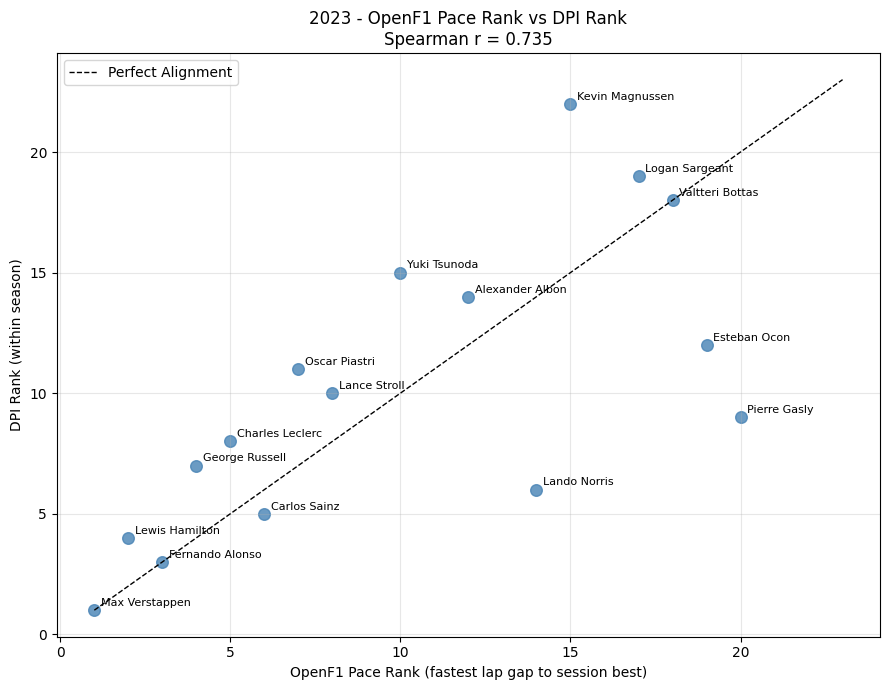

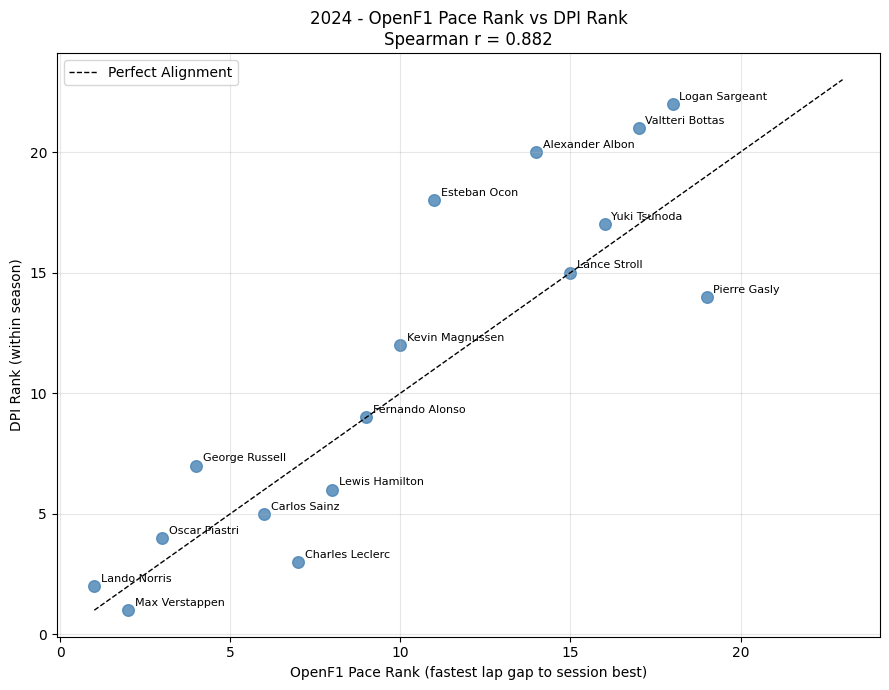

In [18]:
for result in comparison_results:
    year   = result['year']
    r      = result['spearman_r']
    merged = result['merged']

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(merged['pace_rank'], merged['DPI_rank_season'],
               s=70, alpha=0.8, color='steelblue')

    for _, row in merged.iterrows():
        ax.annotate(
            row['driver_name'],
            (row['pace_rank'], row['DPI_rank_season']),
            xytext=(5, 3), textcoords='offset points', fontsize=8
        )

    max_r = int(max(merged['pace_rank'].max(),
                    merged['DPI_rank_season'].max())) + 1
    ax.plot([1, max_r], [1, max_r], 'k--', linewidth=1, label='Perfect Alignment')
    ax.set_title(f'{year} - OpenF1 Pace Rank vs DPI Rank\nSpearman r = {r:.3f}')
    ax.set_xlabel('OpenF1 Pace Rank (fastest lap gap to session best)')
    ax.set_ylabel('DPI Rank (within season)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'openf1_vs_dpi_{year}.png', dpi=150)
    plt.show()

In [19]:
print("Summary of external comparisons:")
print(f"\nFIA Championship Standings (all 5 seasons):")
print(spearman_df[['season','spearman_r','n_drivers']].to_string(index=False))

print(f"\nOpenF1 Pace Metric (2023-2024):")
for result in comparison_results:
    print(f"  {result['year']}: Spearman r = {result['spearman_r']:.3f}  "
          f"(n={result['n_drivers']} drivers matched)")

Summary of external comparisons:

FIA Championship Standings (all 5 seasons):
 season  spearman_r  n_drivers
   2021       0.959         20
   2022       0.919         20
   2023       0.936         22
   2024       0.894         22
   2025       0.906         21

OpenF1 Pace Metric (2023-2024):
  2023: Spearman r = 0.735  (n=16 drivers matched)
  2024: Spearman r = 0.882  (n=16 drivers matched)
